In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:\\Users\\cngan\\Downloads\\car_price_prediction.csv")

In [18]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [19]:
df.drop("ID", axis=1, inplace=True)


In [20]:
df.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [21]:
df["Manufacturer"].value_counts()


Manufacturer
HYUNDAI          3769
TOYOTA           3662
MERCEDES-BENZ    2076
FORD             1111
CHEVROLET        1069
                 ... 
LAMBORGHINI         1
PONTIAC             1
SATURN              1
ASTON MARTIN        1
GREATWALL           1
Name: count, Length: 65, dtype: int64

In [22]:
df["Manufacturer"] = df["Manufacturer"].astype(str)
df["Manufacturer"] = df["Manufacturer"].str.strip().str.upper()


In [23]:
df["Manufacturer"] = df["Manufacturer"].replace({
    "MERCEDES BENZ": "MERCEDES-BENZ",
    "MERCEDESBENZ": "MERCEDES-BENZ",
    "VW": "VOLKSWAGEN"
})


In [24]:
counts = df["Manufacturer"].value_counts()

threshold = 100
rare_brands = counts[counts < threshold].index

df["Manufacturer"] = df["Manufacturer"].replace(rare_brands, "OTHER")


In [25]:
df["Manufacturer"].value_counts()


Manufacturer
HYUNDAI          3769
TOYOTA           3662
MERCEDES-BENZ    2076
FORD             1111
CHEVROLET        1069
BMW              1049
LEXUS             982
HONDA             977
OTHER             904
NISSAN            660
VOLKSWAGEN        579
SSANGYONG         441
KIA               421
OPEL              397
MITSUBISHI        289
SUBARU            275
AUDI              255
MAZDA             183
JEEP              138
Name: count, dtype: int64

In [26]:
df = pd.get_dummies(df, columns=["Manufacturer"], drop_first=True)


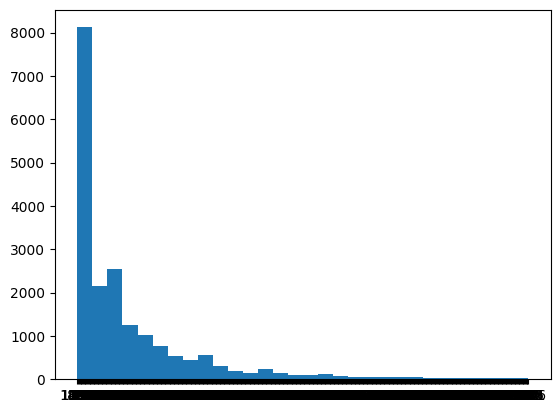

In [30]:
import matplotlib.pyplot as plt

plt.hist(df["Levy"], bins=30)
plt.show()


In [34]:
import numpy as np

df.replace("-", np.nan, inplace=True)


In [35]:
df["Levy"] = pd.to_numeric(df["Levy"], errors="coerce")


In [36]:
df["Levy"].fillna(df["Levy"].mean(), inplace=True)


C:\Users\cngan\AppData\Local\Temp\ipykernel_8632\3610433620.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Levy"].fillna(df["Levy"].mean(), inplace=True)


In [37]:
df["Levy"].skew()


np.float64(6.525336834060719)

In [38]:
print(df["Levy"].dtype)
print(df["Levy"].isnull().sum())


float64
0


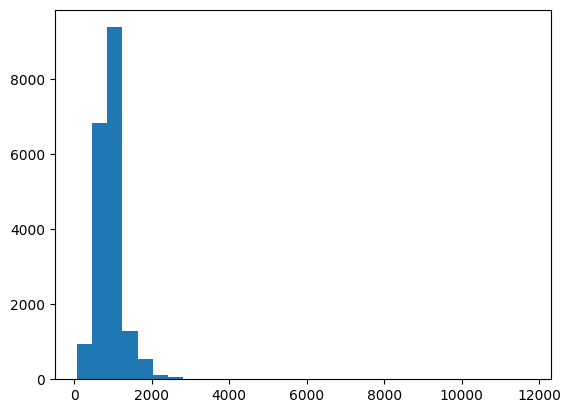

In [39]:
import matplotlib.pyplot as plt

plt.hist(df["Levy"], bins=30)
plt.show()


In [40]:
import numpy as np

df["Levy"] = np.log1p(df["Levy"])


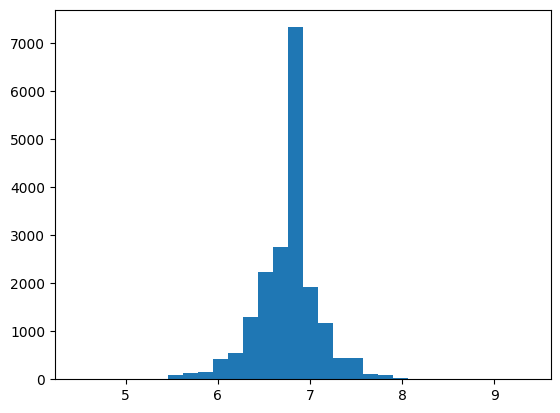

In [41]:
df["Levy"].skew()
plt.hist(df["Levy"], bins=30)
plt.show()



In [42]:
df["Price"].head()
df["Price"].dtype
df["Price"].unique()[:10]


array([13328, 16621,  8467,  3607, 11726, 39493,  1803,   549,  1098,
       26657])

In [43]:
df["Price"] = df["Price"].astype(str)
df["Price"] = df["Price"].str.replace("$", "", regex=False)
df["Price"] = df["Price"].str.replace(",", "", regex=False)
df["Price"] = df["Price"].str.strip()


In [44]:
import numpy as np

df["Price"] = df["Price"].replace("-", np.nan)


In [45]:
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")


In [46]:
df["Price"].dtype


dtype('int64')

In [47]:
df = df.dropna(subset=["Price"])


In [48]:
exchange_rate = 83

df["Price_INR"] = df["Price"] * exchange_rate


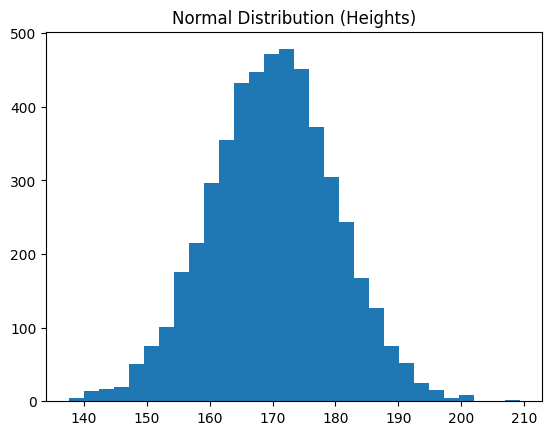

Normal Distribution (Heights)
Mean: 170.06
Median: 170.13
→ Left Skewed



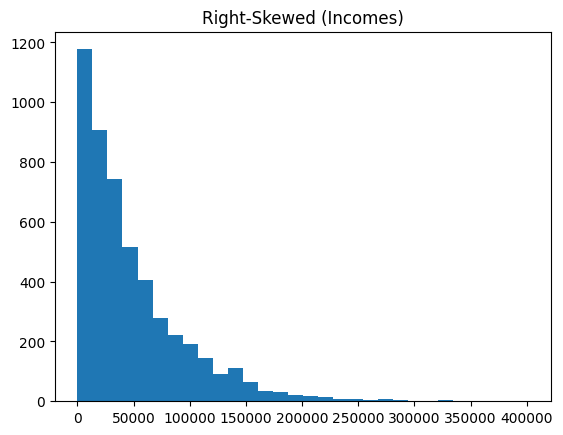

Right-Skewed (Incomes)
Mean: 48457.7
Median: 33850.55
→ Right Skewed



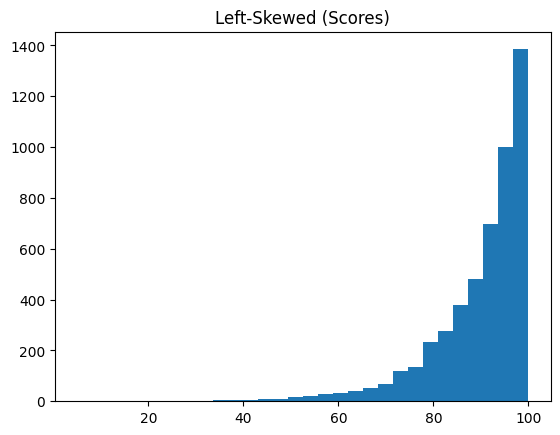

Left-Skewed (Scores)
Mean: 89.88
Median: 93.21
→ Left Skewed



In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)
heights = np.random.normal(170, 10, 5000)
incomes = np.random.exponential(50000, 5000)
scores = 100 - np.random.exponential(10, 5000)
scores = np.clip(scores, 0, 100)
def analyze(data, title):
    mean = np.mean(data)
    median = np.median(data)

    plt.figure()
    plt.hist(data, bins=30)
    plt.title(title)
    plt.show()

    print(title)
    print("Mean:", round(mean,2))
    print("Median:", round(median,2))
    
    if mean > median:
        print("→ Right Skewed\n")
    elif mean < median:
        print("→ Left Skewed\n")
    else:
        print("→ Normal\n")

analyze(heights, "Normal Distribution (Heights)")
analyze(incomes, "Right-Skewed (Incomes)")
analyze(scores, "Left-Skewed (Scores)")


In [51]:
mean = df["Price"].mean()
std = df["Price"].std()
df["z_score"] = (df["Price"] - mean) / std
outliers = df[abs(df["z_score"]) > 3]

print("Number of outliers:", len(outliers))
outliers.head()


Number of outliers: 3


,Price,Levy,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,...,Manufacturer_MITSUBISHI,Manufacturer_NISSAN,Manufacturer_OPEL,Manufacturer_OTHER,Manufacturer_SSANGYONG,Manufacturer_SUBARU,Manufacturer_TOYOTA,Manufacturer_VOLKSWAGEN,Price_INR,z_score
1225,627220,6.811066,G 65 AMG 63AMG,2020,Jeep,Yes,Petrol,6.3 Turbo,0 km,8.0,...,False,False,False,False,False,False,False,False,52059260,3.193725
8541,872946,7.634337,Urus,2019,Universal,Yes,Petrol,4,2531 km,8.0,...,False,False,False,True,False,False,False,False,72454518,4.483075
16983,26307500,6.811066,Combo,1999,Goods wagon,No,Diesel,1.7,99999 km,4.0,...,False,False,True,False,False,False,False,False,2183522500,137.940859
